In [ ]:
# Check the status and details of the GPU(s) available on the system.
# The command 'nvidia-smi' (NVIDIA System Management Interface) provides information
# about the GPU, including its utilization, memory usage, temperature, and running processes.
!nvidia-smi

Thu Jan  9 22:02:56 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   47C    P8              11W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
# Import the TensorFlow library to access its functionalities.
import tensorflow as tf

# Test and retrieve the name of the GPU device being used by TensorFlow.
# This function checks if TensorFlow can access the GPU and returns its name if available.
tf.test.gpu_device_name()

'/device:GPU:0'

In [ ]:
# Import the device_lib module from TensorFlow to access device information.
from tensorflow.python.client import device_lib

# List all local devices available to TensorFlow, including CPUs and GPUs.
# This function provides details about each device, such as its type, name, and memory.
device_lib.list_local_devices()

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 2963834562954668918
 xla_global_id: -1,
 name: "/device:GPU:0"
 device_type: "GPU"
 memory_limit: 14626652160
 locality {
   bus_id: 1
   links {
   }
 }
 incarnation: 8423561167048300993
 physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
 xla_global_id: 416903419]

In [ ]:
!cat /proc/cpuinfo

processor	: 0
vendor_id	: GenuineIntel
cpu family	: 6
model		: 85
model name	: Intel(R) Xeon(R) CPU @ 2.00GHz
stepping	: 3
microcode	: 0xffffffff
cpu MHz		: 2000.124
cache size	: 39424 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm abm 3dnowprefetch invpcid_single ssbd ibrs ibpb stibp fsgsbase tsc_adjust bmi1 hle avx2 smep bmi2 erms invpcid rtm mpx avx512f avx512dq rdseed adx smap clflushopt clwb avx512cd avx512bw avx512vl xsaveopt xsavec xgetbv1 xsaves arat md_clear arch_capabilities
bugs		: cpu_meltdown spectre_v1 spectre_v2 spec_store_bypass l1tf mds swapgs taa mmi

In [ ]:
# Display detailed information about the CPU(s) on the system.
# The command 'cat /proc/cpuinfo' reads the CPU information from the system's proc filesystem,
# providing details such as the number of cores, architecture, model name, and clock speed.
!cat /proc/cpuinfo

processor	: 0
vendor_id	: GenuineIntel
cpu family	: 6
model		: 85
model name	: Intel(R) Xeon(R) CPU @ 2.00GHz
stepping	: 3
microcode	: 0xffffffff
cpu MHz		: 2000.124
cache size	: 39424 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm abm 3dnowprefetch invpcid_single ssbd ibrs ibpb stibp fsgsbase tsc_adjust bmi1 hle avx2 smep bmi2 erms invpcid rtm mpx avx512f avx512dq rdseed adx smap clflushopt clwb avx512cd avx512bw avx512vl xsaveopt xsavec xgetbv1 xsaves arat md_clear arch_capabilities
bugs		: cpu_meltdown spectre_v1 spectre_v2 spec_store_bypass l1tf mds swapgs taa mmi

In [ ]:
# Enable logging for device placement in TensorFlow.
# This will print out information about which device (CPU or GPU) is being used for each operation.
tf.debugging.set_log_device_placement(True)

# Create two constant tensors 'a' and 'b'.
# Tensor 'a' is a 2x3 matrix, and tensor 'b' is a 3x2 matrix.
a = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
b = tf.constant([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])

# Perform matrix multiplication between tensors 'a' and 'b'.
# The result 'c' will be a 2x2 matrix.
c = tf.matmul(a, b)

print(c)

Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op MatMul in device /job:localhost/replica:0/task:0/device:GPU:0
tf.Tensor(
[[22. 28.]
 [49. 64.]], shape=(2, 2), dtype=float32)


In [ ]:
# Explicitly place tensors on the CPU using a context manager.
# This ensures that the following operations are executed on the CPU.
with tf.device('/CPU:0'):
    # Create two constant tensors 'a' and 'b' on the CPU.
    a = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
    b = tf.constant([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])

# Perform matrix multiplication between tensors 'a' and 'b'.
# Since 'a' and 'b' were created on the CPU, this operation will also run on the CPU.
c = tf.matmul(a, b)

print(c)

Executing op MatMul in device /job:localhost/replica:0/task:0/device:GPU:0
tf.Tensor(
[[22. 28.]
 [49. 64.]], shape=(2, 2), dtype=float32)


In [ ]:
# Create a MirroredStrategy for distributing computations across multiple GPUs.
# This strategy allows for synchronous training on multiple GPUs by creating copies of the model on each GPU.
strategy = tf.distribute.MirroredStrategy()

# Define the model within the strategy's scope to ensure that it is replicated across the available GPUs.
with strategy.scope():
    # Define the input layer of the model with a shape of (1,).
    inputs = tf.keras.layers.Input(shape=(1,))

    # Add a Dense layer with 1 output unit to the model.
    predictions = tf.keras.layers.Dense(1)(inputs)

    # Create the Keras model by specifying the inputs and outputs.
    model = tf.keras.models.Model(inputs=inputs, outputs=predictions)

    # Compile the model with Mean Squared Error (mse) as the loss function
    # and Stochastic Gradient Descent (SGD) as the optimizer with a learning rate of 0.2.
    model.compile(loss='mse',
                  optimizer=tf.keras.optimizers.SGD(learning_rate=0.2))

Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op FloorMod in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Cast in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomGetKeyCounter in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandom

In [ ]:
import tensorflow as tf

# List all physical GPU devices available on the system.
gpus = tf.config.list_physical_devices('GPU')

# Check if any GPUs are available.
if gpus:
    try:
        # Enable memory growth for each GPU.
        # This allows TensorFlow to allocate GPU memory incrementally as needed,
        # rather than pre-allocating all available memory at once.
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        # List the logical GPUs created from the physical GPUs.
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')

        # Print the number of physical and logical GPUs detected.
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Catch and print any RuntimeError that occurs.
        # This error may occur if memory growth is set after the GPUs have been initialized.
        print(e)

# Inform the user that TensorFlow will allocate GPU memory as needed during runtime.
print("TF will attempt to allocate only as much GPU memory as needed for the runtime allocations")

1 Physical GPUs, 1 Logical GPUs
TF will attempt to allocate only as much GPU memory as needed for the runtime allocations


In [ ]:
import time

def measure(x, steps):
    # TensorFlow initializes a GPU the first time it's used, exclude from timing.
    tf.matmul(x, x)
    start = time.time()
    for i in range(steps):
        x = tf.matmul(x, x)
    # tf.matmul can return before completing the matrix multiplication
    # (e.g., can return after enqueing the operation on a CUDA stream).
    # The x.numpy() call below will ensure that all enqueued operations
    # have completed (and will also copy the result to host memory,
    # so we're including a little more than just the matmul operation time).
    _ = x.numpy()
    end = time.time()
    return end - start

shape = (1000, 1000)
steps = 200
print("Time to multiply a {} matrix by itself {} times:".format(shape, steps))

# Run on CPU:
with tf.device("/cpu:0"):
    cpu_time1 = measure(tf.random.normal(shape), steps)
    print("CPU: {} secs".format(cpu_time1))

# Run on GPU, if available:
if tf.config.list_physical_devices("GPU"):
    with tf.device("/gpu:0"):
        gpu_time1 = measure(tf.random.normal(shape), steps)
        print("GPU: {} secs".format(gpu_time1))
else:
    print("GPU: not found")

print('GPU speedup over CPU: {}x'.format(int(cpu_time1/gpu_time1)))

Time to multiply a (1000, 1000) matrix by itself 200 times:
CPU: 3.4238595962524414 secs
GPU: 0.15860199928283691 secs
GPU speedup over CPU: 21x


In [ ]:
import timeit
tf.config.run_functions_eagerly(True)

@tf.function
def conv_fn():
    image = tf.random.normal((100, 100, 100, 3))
    net = tf.keras.layers.Conv2D(32, 7)(image)
    return tf.reduce_sum(net)


print("30 loops of convolve 32x7x7x3 filter over random 100x100x100x3 images:")
with tf.device("/cpu:0"):
    cpu_time2 = timeit.timeit(lambda: conv_fn(), number=30)
    print("CPU:", cpu_time2)
if tf.config.list_physical_devices("GPU"):
    with tf.device("/gpu:0"):
        gpu_time2 = timeit.timeit(lambda: conv_fn(), number=30)
        print("GPU:", gpu_time2)
else:
    print("GPU: not found")

print('GPU speedup over CPU: {}x'.format(int(cpu_time2/gpu_time2)))

30 loops of convolve 32x7x7x3 filter over random 100x100x100x3 images:
CPU: 11.904784821000021
GPU: 2.4270296299999927
GPU speedup over CPU: 4x


# TEST 1

In [ ]:
data = range(10)
output = []

def foo(i):
    output.append(i)

[foo(i) for i in data]

output

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [ ]:
import numpy as np
data = np.asarray(range(10))
output = np.zeros(len(data))

def foo(i):
    output[i] = i

[foo(i) for i in data]

output

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

In [ ]:
from numba import cuda

# Create a NumPy array from a range of numbers (0 to 9).
data = np.asarray(range(10))
# Initialize an output array of zeros with the same length as the input data.
output = np.zeros(len(data))

# Define a CUDA kernel function that copies elements from the input array to the output array.
@cuda.jit
def foo(input_array, output_array):
    # Get the unique thread index for the current thread.
    i = cuda.grid(1)
    # Copy the value from the input array to the output array at the thread index.
    output_array[i] = input_array[i]

# Launch the CUDA kernel with 1 block and a number of threads equal to the length of the data.
foo[1, len(data)](data, output)

output

/usr/local/lib/python3.10/dist-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/usr/local/lib/python3.10/dist-packages/numba/cuda/cudadrv/devicearray.py:888: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

In [ ]:
# 1 sec
random_array = np.random.random((30_000_000))

In [ ]:
output = np.zeros_like(random_array)

In [ ]:
# Measure the execution time of the following code block.
%%time
# Define a function that multiplies each element of 'random_array' by 2
# and stores the result in the 'output' array at the corresponding index.
def foo(i):
    output[i] = random_array[i] * 2

# Use a list comprehension to apply the function 'foo' to each index in 'random_array'.
_ = [foo(i) for i in range(len(random_array))]

CPU times: user 10 s, sys: 144 ms, total: 10.2 s
Wall time: 10.2 s


In [ ]:
# Import Math library
import math

In [ ]:
# Initialize an output array with the same shape as 'random_array', filled with zeros.
output = np.zeros_like(random_array)
# Define the number of threads per block for the CUDA kernel.
threads = 128
# Calculate the number of blocks needed based on the size of 'random_array' and the number of threads.
blocks = math.ceil(random_array.shape[0] / threads)

@cuda.jit
def foo(input_array, output_array):
    i = cuda.grid(1)
    output_array[i] = input_array[i] * 2

In [ ]:
%%time
# Launch the CUDA kernel with the specified number of blocks and threads.
foo[blocks, threads](random_array, output)

CPU times: user 211 ms, sys: 968 µs, total: 212 ms
Wall time: 212 ms


In [ ]:
# Transfer the 'random_array' from the host (CPU) to the device (GPU) for processing.
gpu_random_array = cuda.to_device(random_array)

# Allocate and transfer an output array filled with zeros to the GPU,
# which will be used to store the results of computations performed on the GPU.
gpu_output = cuda.to_device(np.zeros_like(random_array))

In [ ]:
%%time
foo[blocks, threads](gpu_random_array, gpu_output)

CPU times: user 0 ns, sys: 301 µs, total: 301 µs
Wall time: 310 µs


In [ ]:
gpu_output.copy_to_host()

array([1.87251764, 0.73838501, 1.47469742, ..., 0.05119047, 0.44666049,
       0.28429293])

In [ ]:
# Exercise: Implement FizzBuzz using CUDA.

# Create an array of integers from 1 to 49,999,999.
data = np.arange(1, 50_000_000)

# Initialize an output array of zeros with the same shape as 'data'.
output = np.zeros_like(data)

# Set number of threads per block.
threads = 128

# Calculate the number of blocks needed.
blocks = math.ceil(data.shape[0] / threads)

# Define a CUDA kernel for FizzBuzz logic.
@cuda.jit
def fizz_buzz(input_array, output_array):
    i = cuda.grid(1)  # Get thread index.
    n = input_array[i]  # Get value from input array.

    # Assign values based on divisibility.
    if n % 3 == 0:
        output_array[i] = 1  # Fizz
    if n % 5 == 0:
        output_array[i] = 2  # Buzz
    if n % 15 == 0:
        output_array[i] = 3  # Fizz Buzz

In [ ]:
%%time
fizz_buzz[blocks, threads](data, output)
output[:12]

/usr/local/lib/python3.10/dist-packages/numba/cuda/cudadrv/devicearray.py:888: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


CPU times: user 464 ms, sys: 2.02 ms, total: 466 ms
Wall time: 466 ms


array([0, 0, 1, 0, 2, 1, 0, 0, 1, 2, 0, 1])

In [ ]:
# Calculate the highest instance of Fizz.
idx = np.where(output == 1)[0][-1]
data[idx]

49999998

# Gaussian blur with Numba

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from numba import cuda
import numpy as np
import math
import requests

plt.rcParams["figure.figsize"] = (30,4)

url = "https://raw.githubusercontent.com/jacobtomlinson/gpu-python-tutorial/main/images/numba.png"
response = requests.get(url)
if response.status_code == 200:
    with open("numba.png", "wb") as file:
        file.write(response.content)
# Read the downloaded image into a variable for plotting.
im = plt.imread("numba.png")

In [ ]:
type(im)

numpy.ndarray

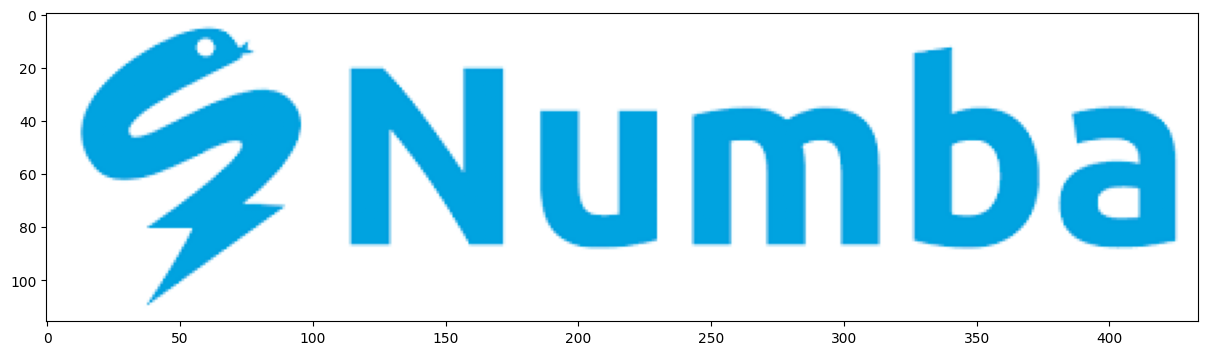

In [ ]:
plt.imshow(im)

In [ ]:
# Transfer the image to the GPU.
gpu_im = cuda.to_device(im)

# Allocate an output array of zeros on the GPU.
gpu_output = cuda.to_device(np.zeros_like(gpu_im))

In [ ]:
im.shape

(116, 434, 4)

In [ ]:
# Define the number of threads per block in a 3D grid.
threadsperblock = (2, 16, 4)

# Calculate the number of blocks needed in each dimension.
blockspergrid_x = math.ceil(gpu_im.shape[0] / threadsperblock[0])
blockspergrid_y = math.ceil(gpu_im.shape[1] / threadsperblock[1])
blockspergrid_z = math.ceil(gpu_im.shape[2] / threadsperblock[2])

# Combine the block counts into a tuple for the grid size.
blockspergrid = (blockspergrid_x, blockspergrid_y, blockspergrid_z)

# Calculate the total number of threads by multiplying threads per block by blocks per grid.
[t * b for t, b in zip(threadsperblock, blockspergrid)]

[116, 448, 4]

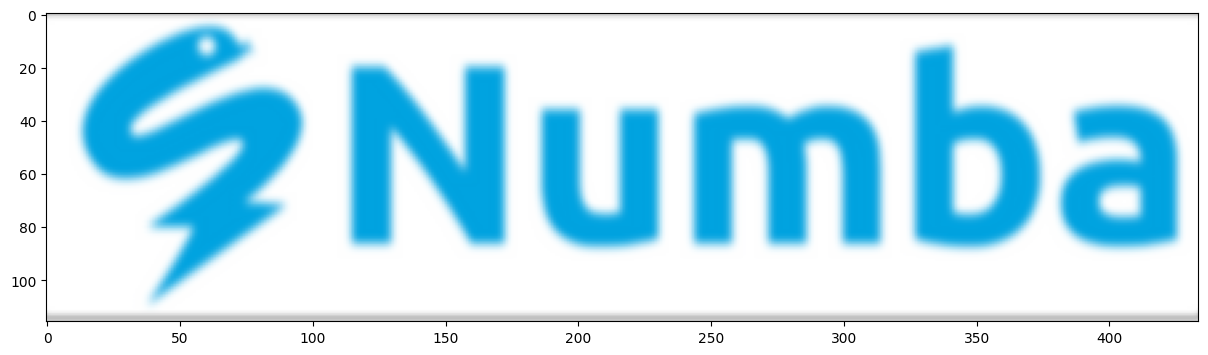

In [ ]:
# Define a CUDA kernel for blurring an image.
@cuda.jit
def blur(im, output):
    # Get the 3D index position in the grid.
    x, y, c = cuda.grid(3)

    # Check if the index is within the image bounds.
    if x < im.shape[0] and y < im.shape[1] and c < im.shape[2]:
        # Calculate the average of the surrounding pixels for blurring.
        output[x, y, c] = (im[x-1, y-1, c] + im[x, y-1, c] + im[x+1, y-1, c] +
                           im[x-1, y, c]   + im[x, y, c]   + im[x+1, y, c] +
                           im[x-1, y+1, c] + im[x, y+1, c] + im[x+1, y+1, c]) / 9

# Apply the blur kernel multiple times to enhance the effect.
for i in range(5):
    blur[blockspergrid, threadsperblock](gpu_im, gpu_output)
    gpu_im, gpu_output = gpu_output, gpu_im  # Swap input and output for the next iteration.

# Display the final blurred image.
plt.imshow(gpu_output.copy_to_host())

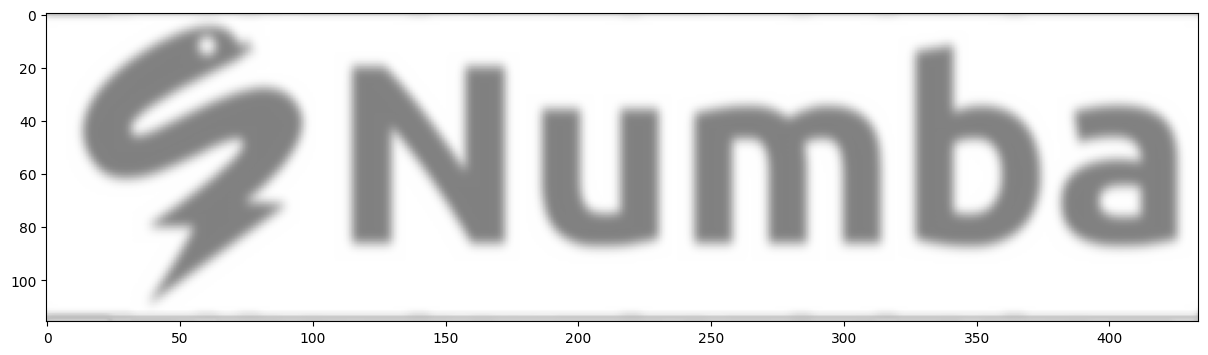

In [ ]:
# Define a CUDA kernel for converting an image to black and white.
@cuda.jit
def black_white(im, output):
    # Get the 2D index position in the grid.
    x, y = cuda.grid(2)

    # Check if the index is within the image bounds.
    if x < im.shape[0] and y < im.shape[1]:
        # Calculate the average of the RGB channels.
        average = (im[x, y, 0] + im[x, y, 1] + im[x, y, 2]) / 3

        # Set all RGB channels in the output to the average.
        output[x, y, 0] = average
        output[x, y, 1] = average
        output[x, y, 2] = average

        # Preserve the alpha channel from the input image.
        output[x, y, 3] = im[x, y, 3]

# Apply the black and white kernel to the image.
black_white[blockspergrid, threadsperblock](gpu_im, gpu_output)

# Display the resulting black and white image.
plt.imshow(gpu_output.copy_to_host())

# What is my GPU doing?

In [ ]:
# Install the NVIDIA Management Library (NVML) Python bindings quietly.
!pip install nvidia-ml-py -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 3.5 MB/s eta 0:00:00


In [ ]:
# Import the PyNVML library for accessing NVIDIA GPU management features.
import pynvml

# Initialize the NVIDIA Management Library (NVML).
pynvml.nvmlInit()

In [ ]:
# Get the number of NVIDIA GPU devices available on the system.
pynvml.nvmlDeviceGetCount()

1

In [ ]:
pynvml.nvmlSystemGetDriverVersion()

'535.104.05'

In [ ]:
gpus = [pynvml.nvmlDeviceGetHandleByIndex(i) for i in range(pynvml.nvmlDeviceGetCount())]
gpus

In [ ]:
[pynvml.nvmlDeviceGetName(gpu) for gpu in gpus]

['Tesla T4']

In [ ]:
[pynvml.nvmlDeviceGetMemoryInfo(gpu).used / 1e9 for gpu in gpus]

[16.052584448]

In [ ]:
[pynvml.nvmlDeviceGetMemoryInfo(gpu).free / 1e9 for gpu in gpus]

[0.053542912]

In [ ]:
import cupy as cp
cp_arr = cp.random.random((1, 100_000, 5_000))

type(cp_arr)

cupy.ndarray

In [ ]:
from numba import cuda
numba_arr = cuda.to_device(cp_arr)
numba_arr

In [ ]:
import torch
torch_arr = torch.as_tensor(numba_arr, device='cuda')
torch_arr

tensor([[[0.1680, 0.7580, 0.1485,  ..., 0.0257, 0.6090, 0.7122],
         [0.0232, 0.0058, 0.4799,  ..., 0.0679, 0.4754, 0.3898],
         [0.4905, 0.8957, 0.6293,  ..., 0.5009, 0.1304, 0.6074],
         ...,
         [0.8615, 0.3332, 0.4755,  ..., 0.7183, 0.2381, 0.6824],
         [0.6916, 0.3899, 0.6308,  ..., 0.9372, 0.8602, 0.1083],
         [0.9424, 0.7833, 0.0129,  ..., 0.8545, 0.8799, 0.3215]]],
       device='cuda:0', dtype=torch.float64)

In [ ]:
type(torch_arr)

torch.Tensor

# CuPy

In [ ]:
# restart kernel
import numpy as np
import cupy as cp
cp.cuda.Stream.null.synchronize()

In [ ]:
%%timeit -r 1 -n 10
x_cpu = np.ones((1000,500,500))

447 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)


In [ ]:
%%timeit -n 10
x_gpu = cp.ones((1000,500,500))

cp.cuda.Stream.null.synchronize()

9.43 ms ± 2.16 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
x_cpu = np.ones((1000,500,500))
x_gpu = cp.ones((1000,500,500))

In [ ]:
%%time
x_cpu *= 5

CPU times: user 186 ms, sys: 1.79 ms, total: 188 ms
Wall time: 188 ms


In [ ]:
%%time
x_gpu *= 5

cp.cuda.Stream.null.synchronize()

CPU times: user 17.8 ms, sys: 0 ns, total: 17.8 ms
Wall time: 18.4 ms


In [ ]:
%%time
x_cpu *= 5
x_cpu *= x_cpu
x_cpu += x_cpu

CPU times: user 575 ms, sys: 1.88 ms, total: 577 ms
Wall time: 579 ms


In [ ]:
%%time
x_gpu *= 5
x_gpu *= x_gpu
x_gpu += x_gpu

cp.cuda.Stream.null.synchronize()

CPU times: user 49 ms, sys: 106 µs, total: 49.1 ms
Wall time: 49.4 ms


In [ ]:
%%time
x_cpu = np.random.random((1000, 1000))
u, s, v = np.linalg.svd(x_cpu)

CPU times: user 1.08 s, sys: 304 ms, total: 1.39 s
Wall time: 744 ms


In [ ]:
%%time
x_gpu = cp.random.random((1000, 1000))
u, s, v = cp.linalg.svd(x_gpu)

CPU times: user 584 ms, sys: 315 ms, total: 899 ms
Wall time: 798 ms


In [ ]:
%%time
x_gpu = cp.random.random((1000, 1000))
u, s, v = np.linalg.svd(x_gpu)  # Note the `np` used here

cp.cuda.Stream.null.synchronize()

CPU times: user 484 ms, sys: 123 ms, total: 607 ms
Wall time: 617 ms


In [ ]:
with cp.cuda.Device(0):
   x_on_gpu0 = cp.random.random((100000, 1000))

x_on_gpu0.device

<CUDA Device 0>

In [ ]:
x_on_gpu0.nbytes / 1e9

0.8

In [ ]:
x_on_gpu0.ndim

2

In [ ]:
x_on_gpu0.size

100000000

In [ ]:
x_on_gpu0.shape

(100000, 1000)

In [ ]:
x_on_gpu0.reshape(10000, 100,-1).shape

(10000, 100, 100)

# cuDF

In [ ]:
# restart kernel
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py -qq

Cloning into 'rapidsai-csp-utils'...
remote: Enumerating objects: 566, done.
remote: Counting objects: 100% (297/297), done.
remote: Compressing objects: 100% (195/195), done.
remote: Total 566 (delta 188), reused 144 (delta 100), pack-reused 269 (from 1)
Receiving objects: 100% (566/566), 182.35 KiB | 9.60 MiB/s, done.
Resolving deltas: 100% (290/290), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 3.7 MB/s eta 0:00:00
Installing RAPIDS Stable 24.10.*
Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.7/567.7 MB 61.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 GB 21.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 167.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.5/915.5 kB 194.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.6/83.6 kB 96.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5

In [ ]:
# Import cuDF for GPU-accelerated DataFrame operations.
import cudf
import pandas as pd

In [ ]:
df = pd.read_csv("https://github.com/jacobtomlinson/gpu-python-tutorial/raw/main/data/pageviews_small.csv", sep=" ")
df.head()

,en.m,Article_51,1,0
0,ja,エレファモン,1,0
1,ang,Flocc:Scīrung,1,0
2,en,Panorama_(La_Dispute_album),1,0
3,fa.m,جاشوا_جکسون,1,0
4,fa.m,خانواده_کندی,2,0


In [ ]:
pageviews = cudf.read_csv("https://github.com/jacobtomlinson/gpu-python-tutorial/raw/main/data/pageviews_small.csv", sep=" ")
pageviews.head()

,en.m,Article_51,1,0
0,ja,エレファモン,1,0
1,ang,Flocc:Scīrung,1,0
2,en,Panorama_(La_Dispute_album),1,0
3,fa.m,جاشوا_جکسون,1,0
4,fa.m,خانواده_کندی,2,0


In [ ]:
# Rename columns
pageviews.columns = ['project', 'page', 'requests', 'x']
# Drop 'x' column
pageviews = pageviews.drop('x', axis=1)

pageviews

,project,page,requests
0,ja,エレファモン,1
1,ang,Flocc:Scīrung,1
2,en,Panorama_(La_Dispute_album),1
3,fa.m,جاشوا_جکسون,1
4,fa.m,خانواده_کندی,2
...,...,...,...
1118994,ja,STUTS,2
1118995,ml.m,മാർച്ച്_18,3
1118996,es.m,Pablo_Sánchez_Velarde,1
1118997,ar,مترو_الجزائر_العاصمة,1


In [ ]:
# Count the number of entries in the cuDF DataFrame where the 'project' column is equal to 'en'.
print(pageviews[pageviews.project == 'en'].count())

project     196882
page        196881
requests    196882
dtype: int64


In [ ]:
# Group the cuDF DataFrame by the 'project' column and count the number of entries for each project.
# Reset the index to convert the grouped result back into a DataFrame format.
grouped_pageviews = pageviews.groupby('project').count().reset_index()
grouped_pageviews

,project,page,requests
0,he.m.d,58,58
1,hy.m.q,1,1
2,nds-nl,33,33
3,fiu-vro,28,28
4,vec.s,4,4
...,...,...,...
1347,ss.m,2,2
1348,roa-tara.m,1,1
1349,he.m.b,27,27
1350,gu.m,232,232


In [ ]:
display(grouped_pageviews[grouped_pageviews.project.isin(['en', 'fr', 'zh', 'pl'])])

,project,page,requests
103,fr,33915,33915
517,pl,11931,11931
584,zh,17577,17577
783,en,196881,196882


In [ ]:
# Convert the 'page' column to uppercase for entries where the 'project' column is equal to 'en'.
uppercase_pages = pageviews[pageviews.project == 'en'].page.str.upper()
uppercase_pages

2                    PANORAMA_(LA_DISPUTE_ALBUM)
9                                 OPERATING_COST
19         RICHARD_BARLOW_(INTELLIGENCE_ANALYST)
27                 ST_VINCENT_AND_THE_GRENADINES
28                                     IAN_MCKEE
                           ...                  
1118958                               DEVIL_GIRL
1118969           PHILOSOPHERS_LEGACY_(HEIRLOOM)
1118973                               KINGS_HILL
1118986                   TIONNE_"T-BOZ"_WATKINS
1118989                             ANTINEUTRINO
Name: page, Length: 196882, dtype: object

In [ ]:
# Filter the cuDF DataFrame for entries where the 'project' column is equal to 'en'.
pageviews_en = pageviews[pageviews.project == 'en']
display(pageviews_en.page.str.upper().head())

2               PANORAMA_(LA_DISPUTE_ALBUM)
9                            OPERATING_COST
19    RICHARD_BARLOW_(INTELLIGENCE_ANALYST)
27            ST_VINCENT_AND_THE_GRENADINES
28                                IAN_MCKEE
Name: page, dtype: object

In [ ]:
# Define a user-defined function (UDF) to apply to the 'requests' column.
def udf(x):
    if x < 5:
        return 0  # Return 0 if the value is less than 5.
    return x  # Return the original value otherwise.

# Apply the UDF to the 'requests' column of the cuDF DataFrame in parallel on the GPU.
pageviews.requests = pageviews.requests.apply(udf)

In [ ]:
pageviews.requests

0          0
1          0
2          0
3          0
4          0
          ..
1118994    0
1118995    0
1118996    0
1118997    0
1118998    0
Name: requests, Length: 1118999, dtype: int64

In [ ]:
pageviews['mul_requests'] = 0.0

In [ ]:
from numba import cuda

@cuda.jit
def multiply(in_col, out_col, multiplier):
    i = cuda.grid(1)
    if i < in_col.size: # boundary guard
        out_col[i] = in_col[i] * multiplier

multiply.forall(len(pageviews))(pageviews['requests'], pageviews['mul_requests'], 10.0)

display(pageviews.head())

,project,page,requests,mul_requests
0,ja,エレファモン,0,0.0
1,ang,Flocc:Scīrung,0,0.0
2,en,Panorama_(La_Dispute_album),0,0.0
3,fa.m,جاشوا_جکسون,0,0.0
4,fa.m,خانواده_کندی,0,0.0


In [ ]:
# rolling window
def neigborhood_mean(window):
    c = 0
    for val in window:
        c += val
    return c / len(window)

pageviews.requests.rolling(3, 1, True).apply(neigborhood_mean)

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
1118994    0.0
1118995    0.0
1118996    0.0
1118997    0.0
1118998    0.0
Name: requests, Length: 1118999, dtype: float64

# cuML

In [ ]:
# Restart the kernel and import cuDF for GPU-accelerated DataFrame operations.
import cudf

# Load a CSV file into a cuDF DataFrame from the specified URL.
df = cudf.read_csv("https://github.com/jacobtomlinson/gpu-python-tutorial/raw/main/data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Drop the 'Outcome' column from the cuDF DataFrame to create the feature set.
X = df.drop(columns=["Outcome"])
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [ ]:
# Extract the 'Outcome' column from the cuDF DataFrame as a NumPy array.
y = df["Outcome"].values
y[0:5]

array([1, 0, 1, 0, 1])

In [ ]:
# Import the train_test_split function from cuML for splitting the dataset.
from cuml.model_selection import train_test_split

# Split the feature set (X) and outcome (y) into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [ ]:
# Import the KNeighborsClassifier from cuML for GPU-accelerated k-nearest neighbors classification.
from cuml.neighbors import KNeighborsClassifier

# Initialize the KNeighborsClassifier with 3 neighbors.
knn = KNeighborsClassifier(n_neighbors=3)

# Fit the model to the training data.
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
# Use the trained KNeighborsClassifier model to make predictions on the test set.
knn.predict(X_test)[0:5]

251    0
325    1
233    0
527    0
464    0
dtype: int64

In [ ]:
# Evaluate the accuracy of the KNeighborsClassifier model on the test set.
knn.score(X_test, y_test)

0.6928104758262634

# Multi-GPU with Dask

In [ ]:
# Import the Client class from Dask for distributed computing.
from dask.distributed import Client

# Create a Dask client to manage distributed computing resources.
client = Client()
client

/usr/local/lib/python3.10/dist-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34985 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:39057
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:34985/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40103'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:46219'
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://127.0.0.1:40741', name: 0, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:40741
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:36018
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://127.0.0.1:37971', name: 1, status: init, memory:

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:34985/status,
Dashboard: http://127.0.0.1:34985/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39057,Workers: 2
Dashboard: http://127.0.0.1:34985/status,Total threads: 2
Started: Just now,Total memory: 12.67 GiB
Comm: tcp://127.0.0.1:40741,Total threads: 1
Dashboard: http://127.0.0.1:45997/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:40103,


In [ ]:
# Submit a simple function to be executed on the Dask cluster.
f = client.submit(lambda: 10 + 1)

# Retrieve and display the result of the submitted function.
f.result()

11

In [ ]:
# Import the Dask array module for handling large arrays.
import dask.array as da
# Create a Dask array with random values, specifying the shape and chunk size.
arr = da.random.random((1000, 1000), chunks=(100, 100))
# Compute the mean of the array and retrieve the result.
arr.mean().compute()

0.4995351696982738

In [ ]:
# Close the Dask client to release resources and shut down the cluster.
client.close()

In [ ]:
# Import LocalCluster from Dask for creating a local distributed computing cluster.
from dask.distributed import LocalCluster

# Create a local Dask cluster for parallel computing.
cluster = LocalCluster()
cluster

/usr/local/lib/python3.10/dist-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35835 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:40791
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:35835/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37805'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40481'
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://127.0.0.1:34195', name: 0, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:34195
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:47626
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://127.0.0.1:44439', name: 1, status: init, memory:

```python
from dask.distributed import SSHCluster

cluster = SSHCluster([
    "localhost",  # Hostname to start the scheduler on
    "10.0.0.2",   # Hostname to start the first worker on
    "10.0.0.3",   # Hostname to start the second worker on
    ...           # etc
])
```

In [ ]:
cluster.close()

INFO:distributed.scheduler:Retire worker addresses (0, 1)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:37805'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:40481'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:47626; closing.
INFO:distributed.scheduler:Remove worker <WorkerState 'tcp://127.0.0.1:34195', name: 0, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1733803072.6076224')
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:47636; closing.
INFO:distributed.scheduler:Remove worker <WorkerState 'tcp://127.0.0.1:44439', name: 1, status: closing, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1733803072.6176329')
INFO:distributed.scheduler:Lost all workers
INFO:distributed.batched:Batched Comm Cl

In [ ]:
from dask_cuda import LocalCUDACluster

cluster = LocalCUDACluster()
cluster

/usr/local/lib/python3.10/dist-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44633 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:44567
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:44633/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:35319'
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://127.0.0.1:41229', name: 0, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:41229
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:41074


In [ ]:
client = Client(cluster)

INFO:distributed.scheduler:Receive client connection: Client-fc722836-b6aa-11ef-aa8a-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:59142


In [ ]:
# Import the CUDA module from Numba for GPU programming.
from numba import cuda

# Define a simple CUDA kernel that increments a counter.
@cuda.jit
def some_kernel():
    i = 0
    while i < 1_000_000:
        i += 1

# Submit the CUDA kernel to the Dask cluster for execution with specified grid and block sizes.
f = client.submit(some_kernel[1024*1024, 1024])
f

<Future: pending, key: <numba.cuda.dispatcher._LaunchConfiguration object-772bec0d459faea12ff97dc6ab3f7ec8>

In [ ]:
import dask
import cudf
import dask_cudf

In [ ]:
# Define a delayed function to generate a partition of time series data.
@dask.delayed
def gen_partition():
    return cudf.datasets.timeseries()

# Create a Dask cuDF DataFrame from multiple delayed partitions.
gddf = dask_cudf.from_delayed([gen_partition() for i in range(30)])
gddf

,id,name,x,y
npartitions=30,,,,
,int64,category,float64,float64
,...,...,...,...
...,...,...,...,...
,...,...,...,...
,...,...,...,...


In [ ]:
gddf.head()

,id,name,x,y
timestamp,,,,
2000-01-01 00:00:00,1015,Xavier,0.577243,0.952064
2000-01-01 00:00:01,1012,Frank,0.601059,-0.737348
2000-01-01 00:00:02,1001,Zelda,-0.270070,-0.617793
2000-01-01 00:00:03,975,Ursula,-0.305278,0.915716
2000-01-01 00:00:04,1007,Norbert,0.577659,0.307704


In [ ]:
gddf.shape[0].compute()

77760030

In [ ]:
# take around 25 seconds
len(gddf)

77760030

In [ ]:
gddf.groupby("name").x.mean().compute()

name
Charlie    -0.000680
Sarah      -0.000726
Wendy      -0.000403
Frank      -0.000492
Kevin       0.000267
Xavier      0.000296
Hannah      0.000297
Ursula     -0.000414
Yvonne      0.000267
Dan        -0.000036
Alice      -0.000706
Patricia   -0.000422
Bob         0.000074
Tim        -0.000308
George     -0.000054
Zelda       0.000271
Michael     0.000123
Jerry       0.000189
Oliver      0.000352
Laura      -0.000176
Edith       0.000366
Victor     -0.000145
Norbert    -0.000041
Ray        -0.000078
Quinn       0.000314
Ingrid      0.000040
Name: x, dtype: float64

In [ ]:
print("Basic statistics:")
print(gddf.describe())

Basic statistics:
Dask DataFrame Structure:
                    id        x        y
npartitions=1                           
               float64  float64  float64
                   ...      ...      ...
Dask Name: concat, 9 expressions
Expr=Concat(frames=[FromDelayed(a1c3a51)['id'].describenumeric(split_every=False), FromDelayed(a1c3a51)['x'].describenumeric(split_every=False), FromDelayed(a1c3a51)['y'].describenumeric(split_every=False)], axis=1)


In [ ]:
print("Column names:")
print(gddf.columns)

Column names:
Index(['id', 'name', 'x', 'y'], dtype='object')


In [ ]:
print("Number of partitions:")
print(gddf.npartitions)

Number of partitions:
30


In [ ]:
# Example usage
def some_non_gpu_function(x):
    return x + 1

def a_gpu_function(foo):
    import cupy as cp
    # Simulate some GPU computation
    return cp.array(foo.result()) ** 2

def another_non_gpu_function(bar):
    return bar.result() - 5

In [ ]:
client.close()
client = Client()

INFO:distributed.scheduler:Remove client Client-0ba7f08d-b6af-11ef-aa8a-0242ac1c000c
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:55408; closing.
INFO:distributed.scheduler:Remove client Client-0ba7f08d-b6af-11ef-aa8a-0242ac1c000c
INFO:distributed.scheduler:Close client connection: Client-0ba7f08d-b6af-11ef-aa8a-0242ac1c000c
INFO:distributed.scheduler:Closing scheduler. Reason: unknown
INFO:distributed.scheduler:Scheduler closing all comms
/usr/local/lib/python3.10/dist-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45637 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:41209
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:45637/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41569'
INFO:d

In [ ]:
# Submit the first non-GPU function

foo = client.submit(some_non_gpu_function,10)
foo

<Future: finished, type: int, key: some_non_gpu_function-a5625e8ceaebbe803355eb76c6bdc21c>

In [ ]:
# Use Dask annotations to submit the GPU function
with dask.annotate(resources={'GPU': 0}):
    bar = client.submit(a_gpu_function, foo)
bar

<Future: pending, key: a_gpu_function-fe84021cceceb5c3e422867ed12e35ce>

In [ ]:

# Submit the second non-GPU function
baz = client.submit(another_non_gpu_function, bar)
baz

<Future: pending, key: another_non_gpu_function-ba773b090a48b8473228975e97dd8442>

In [ ]:
!pip install -qq cosmograph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.8/250.8 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.7/245.7 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.8/202.8 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.7/213.7 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.6/114.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.2/192.2 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd
from cosmograph import cosmo
data_points = pd.read_json('https://gist.githubusercontent.com/Stukova/d2a3bb22c90680b6beaf8a52c3470296/raw/a80fb63f4f4f0135f827c23aff43183de61a153d/points.json', dtype={'id': str})
links = pd.read_json('https://gist.githubusercontent.com/Stukova/d2a3bb22c90680b6beaf8a52c3470296/raw/a80fb63f4f4f0135f827c23aff43183de61a153d/links.json', dtype={'sourceidx': str, 'targetidx': str})

In [ ]:
data_points.columns

Index(['id', 'index', 'value', 'value2', 'date', 'time', 'color', 'label'], dtype='object')

In [ ]:
links.columns

Index(['source', 'sourceidx', 'date', 'time', 'color', 'target', 'targetidx',
       'value'],
      dtype='object')

In [ ]:
graph = cosmo(
   points=data_points,
   links=links,
   point_id_by='id',
   link_source_by='source',
   link_target_by='target',

   point_include_columns=['value'],
   point_label_by='label',
   link_include_columns=['value'],
)
graph.point_size_by = 'value'
graph.link_width_by = 'value'
graph.point_color_by = 'value'
graph.link_color_by = 'value'
graph

Cosmograph(background_color=None, focused_point_ring_color=None, hovered_point_ring_color=None, link_color=Non…

In [ ]:
len(graph.selected_point_ids)

2906

In [ ]:
selected_points = data_points.loc[data_points['id'].isin(graph.selected_point_ids)]
selected_points.head(1)

,id,index,value,value2,date,time,color,label
0,0,0,-5,116,2022-11-25 03:25:04.851000+00:00,1970-01-01T01:20:59.956Z,#bab0ab,offence


In [ ]:
selected_links = links.loc[links.sourceidx.isin(graph.selected_point_ids) & links.targetidx.isin(graph.selected_point_ids)].copy()
selected_links.head(1)

,source,sourceidx,date,time,color,target,targetidx,value
0,0,0,2012-02-08 11:17:27.900000+00:00,1970-01-01T01:06:54.149Z,#4e79a7,1,1,1


In [ ]:
graph_of_selected = cosmo(
   points=selected_points,
   links=selected_links,
   point_id_by='id',
   point_color_by='color',

   link_source_by='source',
   link_target_by='target',
   link_color_by='color'
)
graph_of_selected

Cosmograph(background_color=None, focused_point_ring_color=None, hovered_point_ring_color=None, link_color=Non…

In [ ]:
graph_of_selected.fit_view()

In [ ]:
graph_of_selected.select_points_by_ids(selected_points.query("color == '#af7aa1'").id.tolist())

In [ ]:
graph_of_selected.selected_point_ids

['242', '249', '2714', '3222', '4696', '4763', '5407', '6680', '7260']

In [ ]:
graph_of_selected.fit_view_by_ids(graph_of_selected.selected_point_ids, 2000)

References:

- [cuGraph](https://github.com/rapidsai/cugraph)
- [NVIDIA-ML](https://pypi.org/project/nvidia-ml-py/)
- [Dask](https://www.dask.org/)
- [cuDF](https://docs.rapids.ai/api/cudf/stable/)
- [Numba](https://numba.pydata.org/)